# What is LangGraph

- LangGraph is an orchestration framework for building **intelligent, stateful, and multi-step** LLM workflows.

- It enables advanced features like **parallelism, loops, branching, memory, and resumability** - making it ideal for agentic and production - grade AI applicaitons.

- It models your logic as a **graph of nodes** (tasks) and **edges** (routing) instead of linear chain.


# LLM Workflows

1. LLM workflows are a step by step process using which we can build complex LLM applications.
2. Each step in a workflow performs a distinct task- such as prompting, reasoning, tool calling, memory access, or decision-making
3. Workflows can be linear, parallel, branced or looped, allowing for complex brhaviours like retries, multi-agent communication or tool-augmented reasoning.
4. Common Workflows

### Prompt Chaining

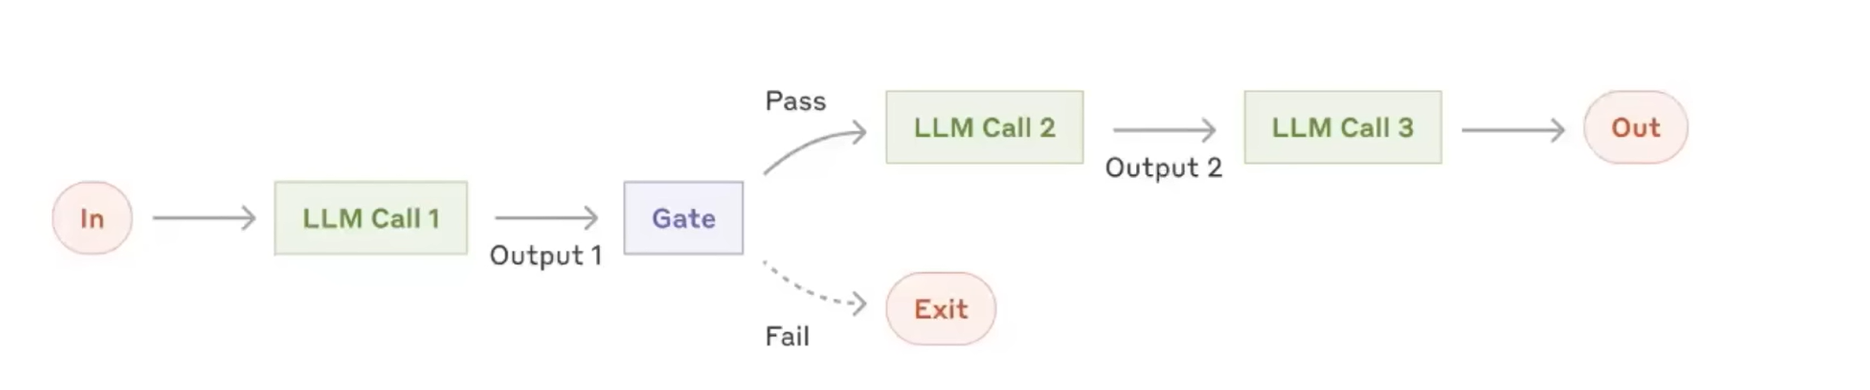


## Routing 

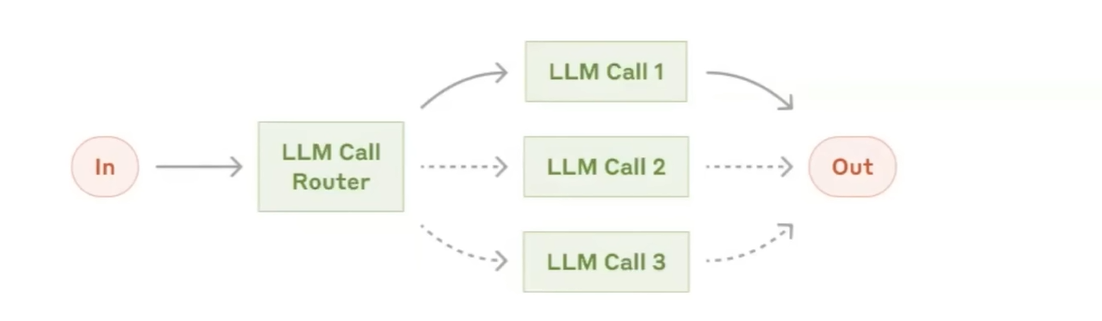

## Parallelization

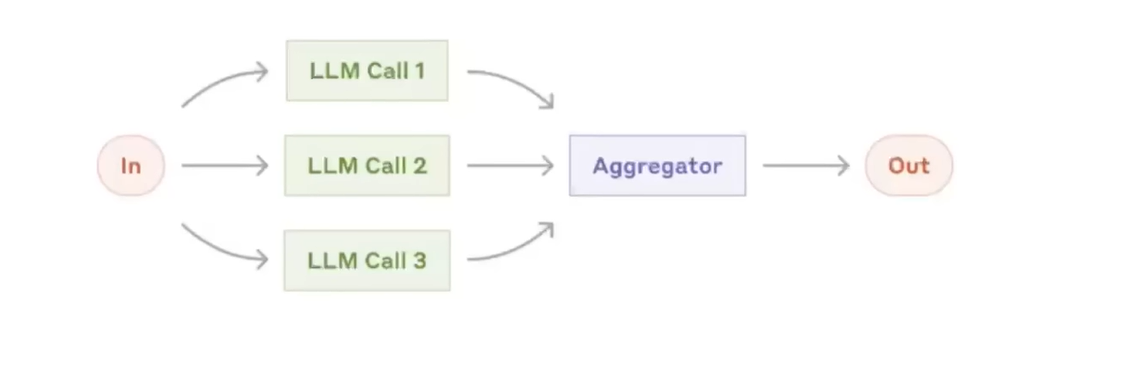

## Orchestrator Workers

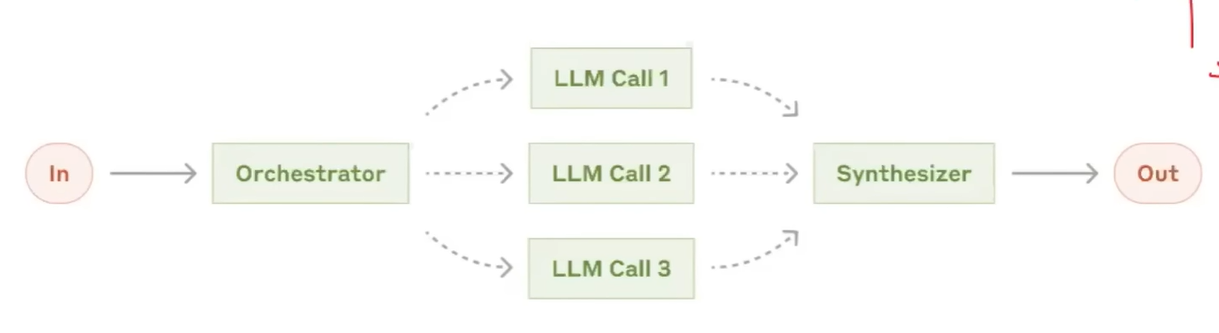

## Evaluator Optimizer

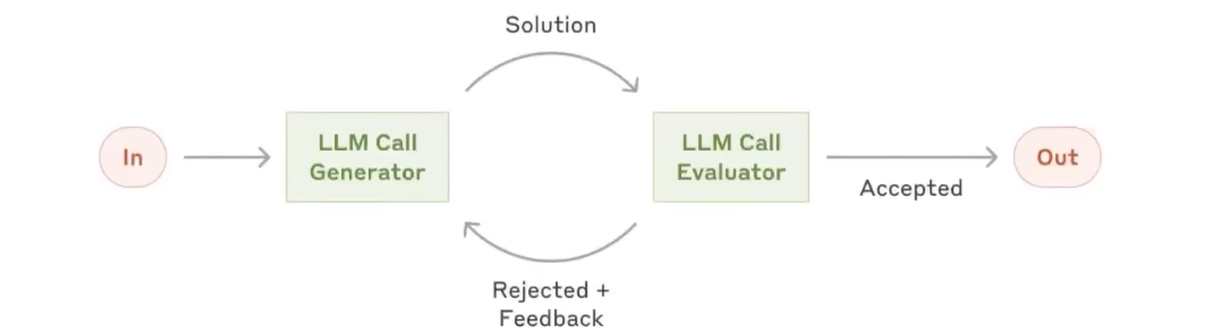

---

# What Graphs, Nodes and Edges

The System generates an essay topic, collects the student's submission and evaluates it in parallel on depth of analysis, language quality, and clarity of thought. Based on the combined score, it either gives feedback for improvement or approves the essay.


1. **GenerateTopic**
   - System generates a relevant UPSC-style essay topic and presents it to the student.

2. **CollectEssay**
   - Student writes and submits the essay based on the generated topic

3. **EvaluateEssay (Parallel Evaluation Block)**
   - Three evaluation tasks run **in parallel**:
     - **EvaluateDepth**- Analyzes depth of analysis, arguemnt strength and critical thinking
     - **EvaluateLanguage**- Checks grammar, vocabulary, fluency and tone.
     - **EvaluateClarity**- Assesses Coherence, logical flow, and clarity of thought.

4. **AggregateResults**
    - Combies the three scores and generates a total score (e.g. out of 15)  


5. **ConditionalRouting**
   - Based on the total score:
       - If Score meets threshold- go to **ShowSuccess**
       - If score is below threshold- go to **GiveFeedback**

6. **GiveFeedback**
    - Provides targeted suggestions for improvement in weak areas.

7. **CollectRevision** (optional loop)
    - Student resubmits the revised essay.
    - loop back to **EvaluateEssay**

8. **ShowSuccess**
    - Congratulates the student and ends the flow


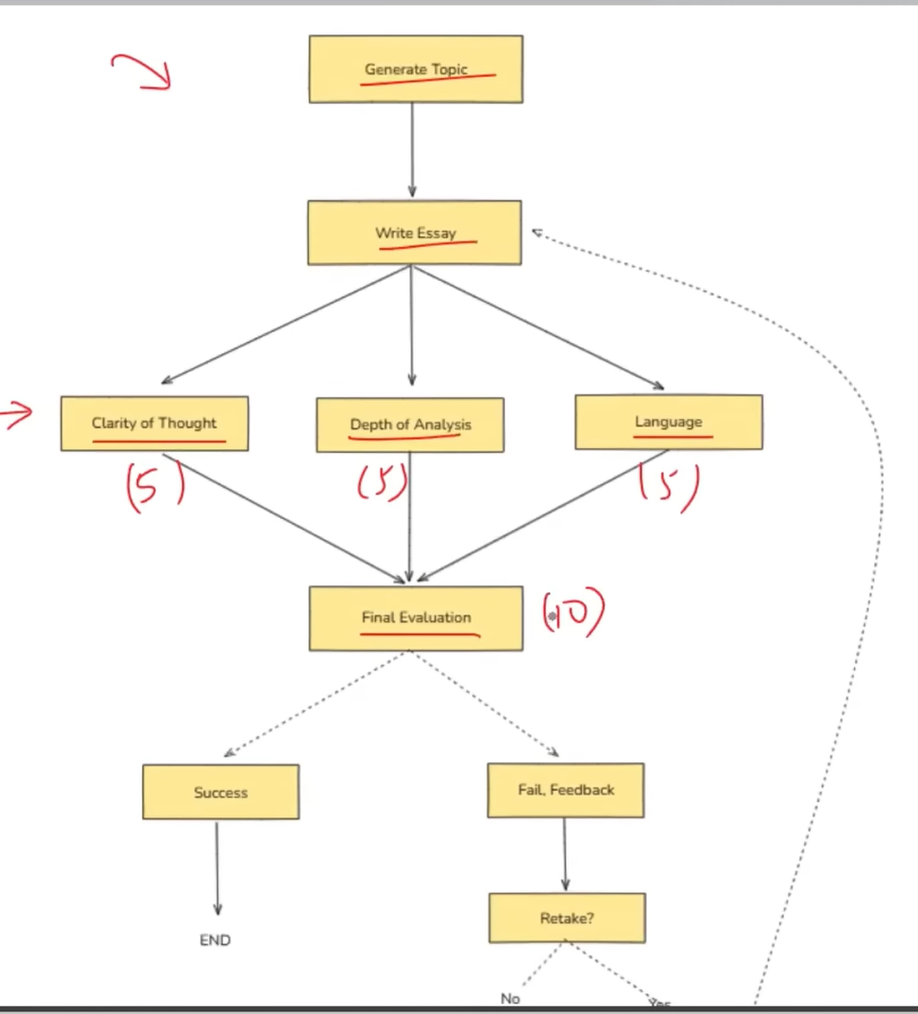

# Reducers
Reducers in LangGraph define how updates from nodes are applied to the shared state.

Each Key in the state can have its own reducer, which determines whether new data replaces, merges or adds to the existing value.

```json
essay_text: str
topic: str
depth_score: int
language_score: int
clarity_score: int
total_score: int
feedback: Annotated[List[str], add]
evaluation_round: int
```

# LangGraph Execution Model

1. **Graph Definition**
You define:
    - The state schema
    - Nodes (functions that perform tasks)
    - Edges (Which node connects to which)
      

2. **Compilation**
- you call `.compile()` on the `StateGraph`.
- This checks the graph  structure and prepares it for execution.

3. **Invocation**
- You ran the graph with `.invoke(initial_state)`
- LangGraph sends the initial state as a **message** to the entry node(s).

4. **Super-Steps Begin**
- Execution proceeds in **rounds**.